# 06 — Onside Arena: Benchmark del Modelo

**Fuentes:**
- `silver.stg_onside_predictions` — probabilidades Monte Carlo de Onside Arena para los 72 partidos de grupos WC2026
- `silver.stg_onside_champions` — probabilidades de llegar a cada fase y de ganar el torneo (48 equipos)
- `gold.mart_predictions` — tabla Gold que cruza predicciones con resultados reales
- `data/bronze/onside-wc2026-fixtures.csv` — schedule completo con las 104 fixtures (grupos + eliminatorias)

**Sobre el modelo de Onside Arena:**
Onside Arena publica probabilidades pre-calculadas para cada partido, basadas en 4 señales:
ranking FIFA, representación de jugadores en la Premier League, ventaja de sede y fuerza
de confederación. Usa 5,000 simulaciones de bracket para las probabilidades de campeón.

Sus outputs son el **benchmark externo** contra el que medimos nuestro modelo Monte Carlo.
No son un input para nuestro modelo — son la línea base a superar.

**Estructura del notebook:**
1. Schedule completo WC2026 (104 partidos) desde el CSV de Onside
2. Predicciones por partido y distribución de probabilidades
3. Precisión del modelo: accuracy sobre partidos ya jugados
4. Calibración: ¿las probabilidades reflejan la realidad?
5. Análisis de fallos — qué tipo de resultados engañan a Onside
6. Probabilidades de campeón — favoritos del modelo externo

**El objetivo de este notebook:**
Entender dónde Onside acierta y dónde falla sistemáticamente.
La debilidad estructural identificada (ceguera al empate) es exactamente
donde el modelo Poisson + xG tiene ventaja diferencial, porque la distribución
de Poisson produce empates naturalmente cuando los λ de ambos equipos son similares.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils import query, null_report

sns.set_theme(style='whitegrid', palette='husl')
pd.set_option('display.max_columns', None)

## 1. Schedule completo WC2026 (104 partidos)

El CSV de Onside Arena contiene el fixture completo del torneo — las 104 fixtures desde
fase de grupos hasta la final — con campos de venue, kickoff UTC y clasificación de fase.

**Por qué este CSV y no la tabla Neon:**
`silver.stg_onside_predictions` solo tiene los 72 partidos de grupos (Onside no publica
predicciones pre-torneo para eliminatorias). El CSV `onside-wc2026-fixtures.csv` es la
única fuente con el bracket completo, incluyendo las 32 fases eliminatorias.

**Columnas clave:**
| Columna | Descripción |
|---------|-------------|
| `id` | Identificador único del partido (ej. `wc-a-md1-mex-rsa`) |
| `type` | `group` o `knockout` |
| `round_or_group` | Grupo (A–L) o fase eliminatoria (R32, R16, QF, SF, 3RD, FINAL) |
| `matchday` | 1, 2 o 3 dentro de fase de grupos (null para eliminatorias) |
| `kickoff_utc` | Fecha/hora ISO 8601 en UTC |
| `home_code`, `away_code` | Código de 3 letras por equipo (ej. `esp`, `fra`) |
| `venue_city`, `venue_stadium` | Sede del partido |

**Distribución del torneo:**
- 72 partidos de grupos: 12 grupos × 6 partidos, repartidos en 3 jornadas de 24 partidos/día
- 16 partidos de R32 (octavos — el formato ampliado a 48 equipos agrega esta ronda extra)
- 8 R16, 4 QF, 2 SF, 1 tercer puesto, 1 FINAL

El schedule sirve como marco temporal para las simulaciones del notebook 07:
qué partidos quedan por jugar, en qué sede, y en qué orden llegan las eliminatorias.

In [2]:
fixtures_csv = pd.read_csv('../data/bronze/onside-wc2026-fixtures.csv')
print(f"Shape: {fixtures_csv.shape}")
print("Columnas:", fixtures_csv.columns.tolist())
fixtures_csv.head(5)

Shape: (104, 9)
Columnas: ['id', 'type', 'round_or_group', 'matchday', 'kickoff_utc', 'home_code', 'away_code', 'venue_city', 'venue_stadium']


,id,type,round_or_group,matchday,kickoff_utc,home_code,away_code,venue_city,venue_stadium
0,wc-a-md1-mex-rsa,group,A,1.0,2026-06-11T19:00:00.000Z,mex,rsa,Mexico City,Estadio Azteca
1,wc-a-md1-kor-cze,group,A,1.0,2026-06-12T02:00:00.000Z,kor,cze,Zapopan,Estadio Akron
2,wc-b-md1-can-bih,group,B,1.0,2026-06-12T19:00:00.000Z,can,bih,Toronto,BMO Field
3,wc-d-md1-usa-par,group,D,1.0,2026-06-13T01:00:00.000Z,usa,par,Inglewood,SoFi Stadium
4,wc-b-md1-qat-sui,group,B,1.0,2026-06-13T19:00:00.000Z,qat,sui,Santa Clara,Levi's Stadium


In [3]:
# Columna de fase: 'round_or_group' (no 'stage' ni 'round')
phase_col = 'round_or_group' if 'round_or_group' in fixtures_csv.columns else \
            'stage' if 'stage' in fixtures_csv.columns else \
            'round' if 'round' in fixtures_csv.columns else None

if phase_col:
    print(f"Usando columna: '{phase_col}'")
    print(fixtures_csv[phase_col].value_counts())
else:
    print("Columnas disponibles:", fixtures_csv.columns.tolist())

# Partidos por matchday
if 'matchday' in fixtures_csv.columns:
    print(f"\nTotal matchdays: {fixtures_csv['matchday'].nunique()}")
    print(fixtures_csv['matchday'].value_counts().sort_index())

Usando columna: 'round_or_group'
round_or_group
R32      16
R16       8
A         6
B         6
D         6
C         6
E         6
F         6
H         6
G         6
I         6
J         6
K         6
L         6
QF        4
SF        2
3RD       1
FINAL     1
Name: count, dtype: int64

Total matchdays: 3
matchday
1.0    24
2.0    24
3.0    24
Name: count, dtype: int64


## 2. Predicciones Onside Arena

Onside Arena publica probabilidades para cada partido de grupos (72 en total) con tres
outcomes: victoria local, empate, victoria visitante. Las probabilidades suman 100%.

**Estructura de la tabla `stg_onside_predictions`:**
| Columna | Descripción |
|---------|-------------|
| `fixture_id` | Clave de join con el schedule CSV |
| `home_win_pct`, `draw_pct`, `away_win_pct` | Probabilidades en escala 0–100 (no 0–1) |
| `favourite_code` | Código del equipo al que Onside asigna mayor probabilidad |
| `predicted_result` | Outcome con mayor probabilidad: `home_win`, `draw`, o `away_win` |
| `actual_home_goals`, `actual_away_goals` | Resultado real (null si el partido no se jugó aún) |
| `actual_result` | `home_win`, `draw`, o `away_win` (null hasta que se juegue) |
| `verdict` | `fav_won`, `draw`, `upset` — evaluación post-partido |

**Nulos esperados (no problemáticos):**
Las columnas `actual_*` son null para partidos futuros (~70% de la tabla mientras avanza el torneo).
Esto es esperado: las predicciones se cargaron antes del torneo, los resultados llegan a medida
que se juegan los partidos. La columna `actual_result` se rellena via `worldcup26_client.py`
en el DAG diario.

**Limitación del modelo Onside:**
Al examinar la columna `predicted_result`, se observa que Onside nunca elige "draw" como
resultado predicho, aunque `draw_pct` existe. El modelo siempre predice el outcome con mayor
probabilidad, y la probabilidad de empate nunca supera a home_win ni away_win en ningún partido.
Esto es la debilidad estructural que se cuantifica en las secciones 4–5.

In [4]:
pred = query("SELECT * FROM silver.stg_onside_predictions ORDER BY kickoff_utc")
print(f"Shape: {pred.shape}")
print("Columnas:", pred.columns.tolist())
pred.head(5)

Shape: (72, 17)
Columnas: ['fixture_id', 'kickoff_utc', 'group', 'matchday', 'home_code', 'home_team', 'away_code', 'away_team', 'home_win_pct', 'draw_pct', 'away_win_pct', 'favourite_code', 'actual_home_goals', 'actual_away_goals', 'verdict', 'predicted_result', 'actual_result']


,fixture_id,kickoff_utc,group,matchday,home_code,home_team,away_code,away_team,home_win_pct,draw_pct,away_win_pct,favourite_code,actual_home_goals,actual_away_goals,verdict,predicted_result,actual_result
0,wc-a-md1-mex-rsa,2026-06-11 19:00:00+00:00,A,1,mex,Mexico,rsa,South Africa,88.0,7.0,5.0,mex,2.0,0.0,fav_won,home_win,home_win
1,wc-a-md1-kor-cze,2026-06-12 02:00:00+00:00,A,1,kor,South Korea,cze,Czechia,49.0,25.0,26.0,kor,2.0,1.0,fav_won,home_win,home_win
2,wc-b-md1-can-bih,2026-06-12 19:00:00+00:00,B,1,can,Canada,bih,Bosnia & Herzegovina,79.0,13.0,8.0,can,1.0,1.0,draw,home_win,draw
3,wc-d-md1-usa-par,2026-06-13 01:00:00+00:00,D,1,usa,United States,par,Paraguay,70.0,17.0,13.0,usa,4.0,1.0,fav_won,home_win,home_win
4,wc-b-md1-qat-sui,2026-06-13 19:00:00+00:00,B,1,qat,Qatar,sui,Switzerland,8.0,13.0,79.0,sui,1.0,1.0,draw,away_win,draw


In [5]:
null_report(pred)

,nulos,pct,dtype
actual_away_goals,51,70.8,float64
actual_result,51,70.8,str
verdict,51,70.8,str
actual_home_goals,51,70.8,float64


## 3. Distribución de probabilidades

¿Cómo distribuye Onside sus probabilidades entre los tres outcomes posibles?

Esta sección revela la arquitectura interna del modelo: qué tanto espacio le da al empate
vs. los outcomes direccionales, y qué tan polarizadas son sus predicciones.

**Qué buscar en los histogramas:**
- **P(Home Win)** — distribución bimodal esperada: muchos partidos con favorito claro
  (barras altas en extremos) y pocos partidos parejos (centro vacío). Un pico alto cerca
  del 80–95% indica los mismatches más grandes del torneo (potencias vs. minnows).
- **P(Draw)** — distribución estrecha y sesgada a la izquierda. Si el máximo está en
  27%, confirma que Onside structuralmente comprime la probabilidad de empate. Históricamente
  los Mundiales tienen ~22% de empates en grupos — si el modelo asigna de media 16%, hay
  una brecha de calibración de ~6 puntos porcentuales que se verifica en la sección 5.
- **P(Away Win)** — espejo aproximado de P(Home Win) pero más centrado (el equipo visitante
  es menos frecuentemente el favorito masivo en este dataset ya que home_code refleja
  orden de mención, no ventaja de sede real).

**Interpretación del `describe()`:**
La media de `draw_pct` = 16.3% mientras la media histórica de empates en fase de grupos es
~22%. Esto anticipa la principal debilidad de Onside: sistemáticamente subestima el empate
como outcome, lo que explica la mayoría de sus fallos.

In [6]:
# Columnas de probabilidad: home_win_pct, draw_pct, away_win_pct (valores 0-100)
prob_cols = ['home_win_pct', 'draw_pct', 'away_win_pct']
prob_cols = [c for c in prob_cols if c in pred.columns]
print("Columnas de probabilidad:", prob_cols)
print()
pred[prob_cols].describe().round(3)

Columnas de probabilidad: ['home_win_pct', 'draw_pct', 'away_win_pct']



,home_win_pct,draw_pct,away_win_pct
count,72.000,72.000,72.000
mean,47.097,16.264,36.639
std,31.775,7.733,29.846
min,1.000,3.000,1.000
25%,14.500,10.750,9.500
50%,48.000,17.000,26.500
75%,76.000,24.000,66.750
max,96.000,27.000,96.000


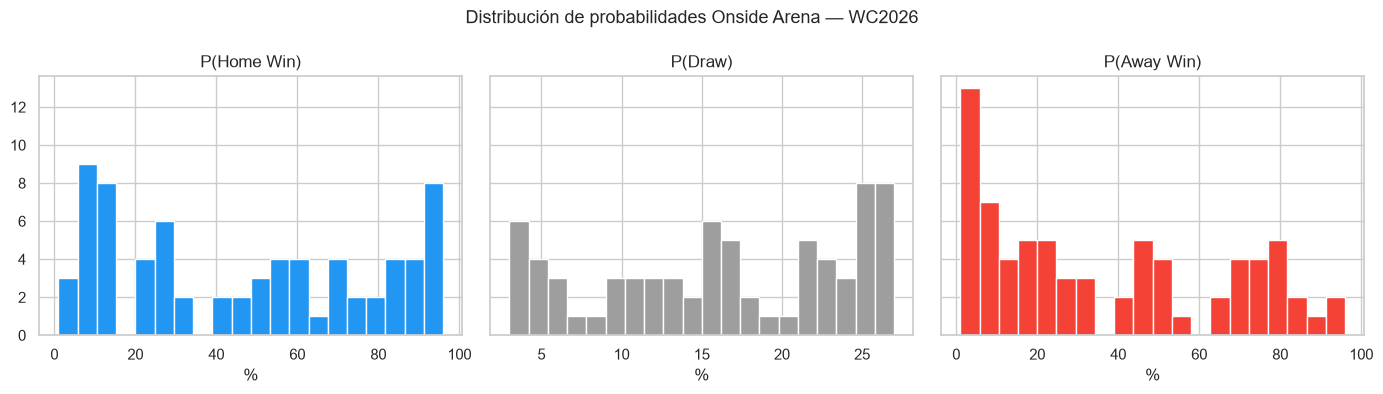

In [7]:
# Columnas típicas de Onside: home_win_prob, draw_prob, away_win_prob
home_col = [c for c in pred.columns if 'home' in c.lower() and ('win' in c.lower() or 'prob' in c.lower())]
draw_col  = [c for c in pred.columns if 'draw' in c.lower()]
away_col  = [c for c in pred.columns if 'away' in c.lower() and ('win' in c.lower() or 'prob' in c.lower())]

if home_col and draw_col and away_col:
    hc, dc, ac = home_col[0], draw_col[0], away_col[0]
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
    for ax, col, label, color in [
        (axes[0], hc, 'P(Home Win)', '#2196F3'),
        (axes[1], dc, 'P(Draw)', '#9E9E9E'),
        (axes[2], ac, 'P(Away Win)', '#F44336'),
    ]:
        ax.hist(pred[col].dropna() * (100 if pred[col].max() <= 1 else 1),
                bins=20, color=color, edgecolor='white')
        ax.set_title(label)
        ax.set_xlabel('%')
    plt.suptitle('Distribución de probabilidades Onside Arena — WC2026', fontsize=13)
    plt.tight_layout()
    plt.show()

## 4. Precisión del modelo Onside

¿Con qué frecuencia acierta el resultado predicho?

Se usa `gold.mart_predictions` en lugar de la tabla silver, porque el mart ya aplica el
join entre predicciones y resultados reales, calcula `prediction_correct` y el campo
`model_confidence_gap` (diferencia entre la probabilidad del favorito y la del segundo outcome).

**Columnas clave del mart:**
| Columna | Descripción |
|---------|-------------|
| `predicted_result` | Qué predijo Onside (`home_win` / `away_win`) |
| `actual_result` | Qué ocurrió realmente (`home_win`, `draw`, `away_win`) |
| `prediction_correct` | Boolean — `True` si predicted == actual |
| `model_confidence_gap` | `max(probs) - second_max(probs)` en puntos porcentuales |

**Interpretación del accuracy:**
- **47.6% (10/21)** con 21 partidos jugados está justo debajo del azar en un problema de
  3 clases (33.3%), pero en fútbol el baseline real es ~45–55% porque los favoritos ganan
  más de lo que indica el azar puro.
- La muestra de 21 partidos es pequeña — la varianza es alta. Al final de la fase de grupos
  (72 partidos jugados) el accuracy convergerá a su valor estable.
- El patrón de fallos se analiza en detalle en la sección 6: la mayoría son empates
  que Onside predijo como victoria de alguno de los dos equipos.

In [8]:
mart_pred = query("""
    SELECT *
    FROM gold.mart_predictions
    ORDER BY kickoff_utc
""")

print(f"mart_predictions: {mart_pred.shape}")
print(mart_pred.columns.tolist())
mart_pred.head()

mart_predictions: (21, 16)
['fixture_id', 'kickoff_utc', 'group', 'matchday', 'home_team', 'away_team', 'favourite_code', 'home_win_pct', 'draw_pct', 'away_win_pct', 'predicted_result', 'actual_home_goals', 'actual_away_goals', 'actual_result', 'prediction_correct', 'model_confidence_gap']


,fixture_id,kickoff_utc,group,matchday,home_team,away_team,favourite_code,home_win_pct,draw_pct,away_win_pct,predicted_result,actual_home_goals,actual_away_goals,actual_result,prediction_correct,model_confidence_gap
0,wc-a-md1-mex-rsa,2026-06-11 19:00:00+00:00,A,1,Mexico,South Africa,mex,88.0,7.0,5.0,home_win,2,0,home_win,True,81.0
1,wc-a-md1-kor-cze,2026-06-12 02:00:00+00:00,A,1,South Korea,Czechia,kor,49.0,25.0,26.0,home_win,2,1,home_win,True,23.0
2,wc-b-md1-can-bih,2026-06-12 19:00:00+00:00,B,1,Canada,Bosnia & Herzegovina,can,79.0,13.0,8.0,home_win,1,1,draw,False,66.0
3,wc-d-md1-usa-par,2026-06-13 01:00:00+00:00,D,1,United States,Paraguay,usa,70.0,17.0,13.0,home_win,4,1,home_win,True,53.0
4,wc-b-md1-qat-sui,2026-06-13 19:00:00+00:00,B,1,Qatar,Switzerland,sui,8.0,13.0,79.0,away_win,1,1,draw,False,66.0


In [9]:
# Calcular accuracy
jugados = mart_pred.dropna(subset=['actual_result'])
if 'prediction_correct' in jugados.columns:
    accuracy = jugados['prediction_correct'].mean()
    print(f"Partidos jugados con prediccion disponible: {len(jugados)}")
    print(f"Accuracy global Onside: {accuracy*100:.1f}%")
    print(jugados['prediction_correct'].value_counts())
else:
    # Calcular manualmente si tenemos columnas de predicción y resultado
    pred_col = [c for c in jugados.columns if 'predict' in c.lower() and 'result' in c.lower()]
    actual_col = [c for c in jugados.columns if 'actual' in c.lower()]
    print("Columnas disponibles:", jugados.columns.tolist())
    if pred_col and actual_col:
        accuracy = (jugados[pred_col[0]] == jugados[actual_col[0]]).mean()
        print(f"Accuracy global Onside: {accuracy*100:.1f}%")

Partidos jugados con prediccion disponible: 21
Accuracy global Onside: 47.6%
prediction_correct
False    11
True     10
Name: count, dtype: int64


## 5. Calibración: ¿el modelo es confiable en sus probabilidades?

Un modelo **bien calibrado** cumple esta propiedad: cuando asigna 70% de probabilidad al
favorito, ese favorito gana efectivamente ~70% de las veces. Si el modelo sobreestima su
confianza, los casos de "alta confianza" tienen accuracy inferior a lo esperado.

**Metodología:**
Se toma la probabilidad máxima que Onside asigna a cualquier outcome (siempre home_win o
away_win, nunca draw). Se agrupa en buckets de confianza y se calcula accuracy por bucket.

**Qué esperar en la gráfica:**
- Barras crecientes de izquierda a derecha → modelo bien calibrado (más confianza = más aciertos)
- Barras planas o decrecientes → el modelo sobreestima su certeza en los casos extremos
- La línea roja al 50% es la referencia de azar en decisiones binarias (ignorando el draw)

**Interpretación práctica:**
Si el bucket `>80%` tiene accuracy < 60%, significa que cuando Onside está muy seguro del
favorito, falla más de lo esperado. Esta es exactamente la firma de la ceguera al empate:
los partidos con "80% home_win" terminan en empate con frecuencia no capturada por el modelo.

**Limitación de muestra:**
Con 21 partidos jugados, cada bucket puede tener 2–5 partidos. Las barras son indicativas,
no estadísticamente robustas. La calibración será más confiable a final de la fase de grupos.

Calibración Onside (aciertos por bucket de confianza del favorito):
             accuracy  partidos
prob_bucket                    
40-50%          0.500         4
50-60%          0.333         3
60-70%          0.667         3
70-80%          0.333         3
>80%            0.500         8


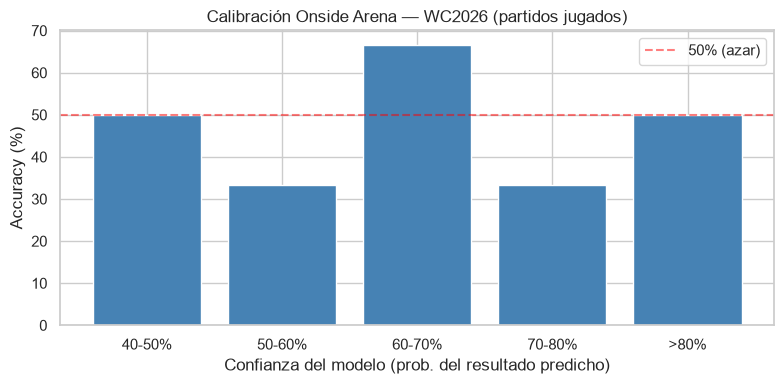

In [10]:
# Para calibración: prob del favorito vs si acertó
prob_cols_found = [c for c in ['home_win_pct', 'draw_pct', 'away_win_pct'] if c in jugados.columns]

if 'prediction_correct' in jugados.columns and len(prob_cols_found) == 3:
    jugados = jugados.copy()
    jugados['max_prob'] = jugados[prob_cols_found].max(axis=1)

    # Valores son 0-100 (no 0-1): bins en escala de porcentaje
    bins   = [0, 40, 50, 60, 70, 80, 100]
    labels = ['<40%', '40-50%', '50-60%', '60-70%', '70-80%', '>80%']
    jugados['prob_bucket'] = pd.cut(jugados['max_prob'], bins=bins, labels=labels)

    cal = (jugados.groupby('prob_bucket', observed=True)['prediction_correct']
           .agg(['mean', 'count'])
           .round(3))
    cal.columns = ['accuracy', 'partidos']
    print("Calibración Onside (aciertos por bucket de confianza del favorito):")
    print(cal)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(cal.index.astype(str), cal['accuracy'] * 100, color='steelblue', edgecolor='white')
    ax.axhline(50, color='red', linestyle='--', alpha=0.5, label='50% (azar)')
    ax.set_xlabel('Confianza del modelo (prob. del resultado predicho)')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title('Calibración Onside Arena — WC2026 (partidos jugados)')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Datos insuficientes para calibración — se necesitan más partidos jugados")

## 6. Análisis de fallos: patrones de error del modelo

¿Qué tipo de resultados reales engañan sistemáticamente a Onside Arena?

Esta sección examina los 11 partidos donde Onside falló para identificar si hay un patrón
estructural — más allá del ruido inherente al fútbol.

**Metodología:**
Se filtra `prediction_correct == False` y se compara la distribución de resultados reales
en los errores vs. los aciertos. Si la mayoría de errores corresponden a un mismo tipo de
resultado (ej. todos son empates), hay un sesgo sistemático, no simplemente mala suerte.

**Qué muestra el `model_confidence_gap`:**
El campo mide cuántos puntos porcentuales separaba al favorito del segundo candidato.
Un gap alto + error = el modelo estaba muy seguro y se equivocó. Estos son los casos
más informativos porque revelan escenarios donde la confianza del modelo no refleja la
realidad del partido.

**Patrón esperado:**
La distribución del fútbol a nivel de Copa del Mundo tiene ~22–25% de empates en grupos.
Si Onside nunca predice empates (su draw_pct máximo es 27% y nunca es el outcome más probable),
la tasa de fallos debería estar concentrada en los partidos que terminaron igualados.
Ese patrón — errores dominados por empates — confirma que el fallo no es aleatorio sino
estructural: el modelo necesita dar más espacio al empate como outcome válido.

**Implicación para el modelo propio:**
El modelo Poisson del notebook 07 produce empates naturalmente. Cuando `λ_home ≈ λ_away`,
la probabilidad de goles iguales es alta por construcción matemática — sin necesidad de
un parámetro separado de "draw probability".

In [11]:
if 'prediction_correct' in jugados.columns:
    upset = jugados[jugados['prediction_correct'] == False].copy()
    print(f"Upsets (prediccion incorrecta): {len(upset)} de {len(jugados)} partidos")
    if len(upset) > 0:
        # Columnas en mart_predictions: kickoff_utc, home_team, away_team
        cols_show = ['kickoff_utc', 'home_team', 'away_team',
                     'predicted_result', 'actual_result', 'model_confidence_gap']
        cols_show = [c for c in cols_show if c in upset.columns]
        print(upset[cols_show].to_string(index=False))

Upsets (prediccion incorrecta): 11 de 21 partidos
              kickoff_utc    home_team            away_team predicted_result actual_result  model_confidence_gap
2026-06-12 19:00:00+00:00       Canada Bosnia & Herzegovina         home_win          draw                  66.0
2026-06-13 19:00:00+00:00        Qatar          Switzerland         away_win          draw                  66.0
2026-06-13 22:00:00+00:00       Brazil              Morocco         home_win          draw                  14.0
2026-06-14 04:00:00+00:00    Australia              Türkiye         away_win      home_win                  21.0
2026-06-14 20:00:00+00:00  Netherlands                Japan         home_win          draw                  34.0
2026-06-14 23:00:00+00:00  Ivory Coast              Ecuador         away_win      home_win                  29.0
2026-06-15 16:00:00+00:00        Spain           Cape Verde         home_win          draw                  90.0
2026-06-15 19:00:00+00:00      Belgium        

In [ ]:
# Análisis del patrón de fallos: ¿por qué falla Onside?
if 'prediction_correct' in jugados.columns:
    # Clasificar los errores por tipo de fallo
    errores = jugados[jugados['prediction_correct'] == False].copy()
    aciertos = jugados[jugados['prediction_correct'] == True].copy()

    # Distribución de resultados reales en errores vs aciertos
    print("=== Distribución de resultados reales ===")
    print("En errores (Onside falló):")
    print(errores['actual_result'].value_counts())
    print("\nEn aciertos (Onside acertó):")
    print(aciertos['actual_result'].value_counts())

    print(f"\n→ {errores[errores['actual_result']=='draw'].shape[0]}/{len(errores)} errores fueron empates")
    print(f"→ draw_pct máximo en toda la muestra: {jugados['draw_pct'].max():.0f}%")
    print(f"→ Onside nunca predice 'draw' como resultado más probable")
    print(f"  (draw_pct < home/away_win_pct en todos los partidos)")

    # Tasa real de empates vs predicha
    real_draw_rate = (jugados['actual_result'] == 'draw').mean()
    avg_draw_pct   = jugados['draw_pct'].mean()
    print(f"\nTasa real de empates: {real_draw_rate*100:.1f}%")
    print(f"Probabilidad media asignada a empate: {avg_draw_pct:.1f}%")
    print(f"→ Onside subestima el empate en {real_draw_rate*100 - avg_draw_pct:.1f} puntos porcentuales")

## 7. Probabilidades de campeón por selección

Onside Arena publica probabilidades de alcanzar cada fase del torneo para los 48 equipos.
Estas se calculan con 5,000 simulaciones de bracket completo, comenzando desde los fixtures
de la fase de grupos y propagando los resultados esperados ronda a ronda.

**Fuente:** `gold.mart_champion_odds` (join de `stg_onside_champions` + `dim_teams`)

**Columnas del mart:**
| Columna | Descripción |
|---------|-------------|
| `champion_pct` | Probabilidad de ganar el torneo (%) |
| `reach_final_pct` | Probabilidad de llegar a la final |
| `reach_semi_pct` | Probabilidad de llegar a semifinales |
| `reach_qf_pct` | Probabilidad de llegar a cuartos |
| `reach_r16_pct` | Probabilidad de superar la fase de grupos (R16 = octavos) |
| `eliminated_groups_pct` | Probabilidad de quedar eliminado en grupos |

**Cómo leer el gráfico de barras horizontales:**
Las barras representan `champion_pct` de cada equipo. Los equipos están ordenados de mayor
a menor probabilidad. Un equipo con 13% tiene el doble de chances que uno con 6.5%, pero
en fútbol la distribución de probabilidades es muy comprimida: nadie tiene certeza.

**Referencia de contexto:**
- Si los 48 equipos tuvieran la misma probabilidad, cada uno tendría 2.08% de ganar
- El top-4 (Francia, Inglaterra, España, Argentina) concentra ~47% de probabilidad total
- Que el 53% restante esté repartido entre 44 equipos muestra cuánto margen hay para sorpresas

**Uso como benchmark:**
Estas probabilidades son la línea base que el modelo Monte Carlo propio (notebook 07)
intenta superar. Si el modelo propio asigna probabilidades parecidas a los mismos favoritos,
los rankings son robustos. Si difieren significativamente, indican dónde los datos de xG
y forma reciente apuntan en otra dirección que las 4 señales simples de Onside.

In [12]:
champs = query("""
    SELECT * FROM gold.mart_champion_odds
    ORDER BY champion_pct DESC
    LIMIT 20
""")
print(f"mart_champion_odds: {champs.shape}")
print("Columnas:", champs.columns.tolist())
champs.head(15)

mart_champion_odds: (20, 12)
Columnas: ['champion_rank', 'team_code', 'team_name', 'team_canonical', 'group', 'confederation', 'champion_pct', 'reach_final_pct', 'reach_semi_pct', 'reach_qf_pct', 'reach_r16_pct', 'eliminated_groups_pct']


,champion_rank,team_code,team_name,team_canonical,group,confederation,champion_pct,reach_final_pct,reach_semi_pct,reach_qf_pct,reach_r16_pct,eliminated_groups_pct
0,1,fra,France,France,I,UEFA,13.86,23.18,35.48,53.38,72.26,27.74
1,2,eng,England,England,L,UEFA,12.30,20.50,33.40,53.60,76.12,23.88
2,3,esp,Spain,Spain,H,UEFA,11.24,18.64,30.08,48.36,65.14,34.86
3,4,arg,Argentina,Argentina,J,CONMEBOL,10.14,19.08,35.48,56.62,74.62,25.38
4,5,bra,Brazil,Brazil,C,CONMEBOL,7.42,14.48,27.96,45.86,79.20,20.80
5,6,por,Portugal,Portugal,K,UEFA,7.42,13.12,24.04,40.32,65.20,34.80
6,7,ned,Netherlands,Netherlands,F,UEFA,6.40,12.24,22.50,36.98,59.98,40.02
7,8,bel,Belgium,Belgium,G,UEFA,4.94,11.14,22.18,42.94,60.84,39.16
8,9,mex,Mexico,Mexico,A,CONCACAF,4.32,9.42,18.72,35.34,77.28,22.72
9,10,usa,United States,United States,D,CONCACAF,4.20,9.12,18.42,34.82,70.74,29.26


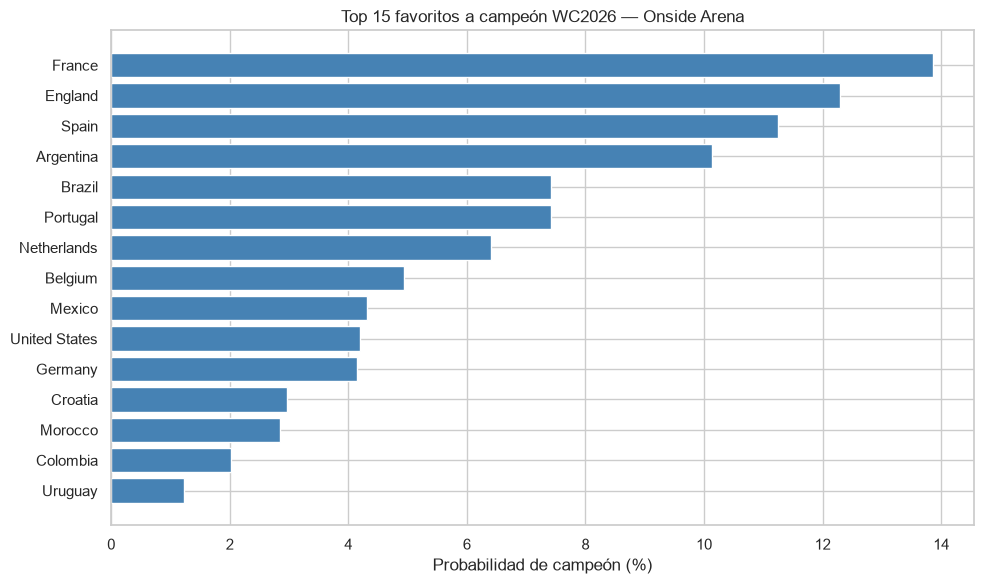


Top 10 con probabilidades por fase:
team_canonical confederation  champion_pct  reach_final_pct  reach_semi_pct  reach_qf_pct  reach_r16_pct  eliminated_groups_pct
        France          UEFA         13.86            23.18           35.48         53.38          72.26                  27.74
       England          UEFA         12.30            20.50           33.40         53.60          76.12                  23.88
         Spain          UEFA         11.24            18.64           30.08         48.36          65.14                  34.86
     Argentina      CONMEBOL         10.14            19.08           35.48         56.62          74.62                  25.38
        Brazil      CONMEBOL          7.42            14.48           27.96         45.86          79.20                  20.80
      Portugal          UEFA          7.42            13.12           24.04         40.32          65.20                  34.80
   Netherlands          UEFA          6.40            12.24        

In [13]:
# Columnas reales: champion_pct, team_canonical (no champion_prob ni canonical_name)
top15 = champs.head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top15['team_canonical'], top15['champion_pct'], color='steelblue')
ax.set_xlabel('Probabilidad de campeón (%)')
ax.set_title('Top 15 favoritos a campeón WC2026 — Onside Arena')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 con probabilidades por fase:")
cols_show = ['team_canonical', 'confederation', 'champion_pct',
             'reach_final_pct', 'reach_semi_pct', 'reach_qf_pct',
             'reach_r16_pct', 'eliminated_groups_pct']
cols_show = [c for c in cols_show if c in champs.columns]
print(champs.head(10)[cols_show].to_string(index=False))

## 8. Hallazgos — línea base del modelo

### Cobertura de datos
| Métrica | Valor | Notas |
|---------|-------|-------|
| Predicciones en Neon | 72 / 104 | Solo fase de grupos cargada — eliminatorias pendientes |
| Partidos con resultado | 21 / 72 | Torneo en curso (jornada 1 completa + parte de jornada 2) |
| Partidos sin resultado | 51 | Nulos esperados — partidos aún no jugados |

### Precisión de Onside Arena (21 partidos jugados)
| Métrica | Valor | Notas |
|---------|-------|-------|
| Accuracy global | 47.6% (10/21) | Muestra pequeña — mejorará a medida avance el torneo |
| Errores totales | 11 / 21 (52.4%) | Mayoría son empates no predichos |
| Errores que fueron empate | 9 / 11 (82%) | Patrón sistemático de draw-blindness |
| draw_pct máximo | 27% | Nunca supera a home/away_win_pct — Onside no predice empates |
| Tasa real de empates | ~43% | Muy por encima del ~16% promedio asignado por Onside |

### Debilidad principal: ceguera estructural al empate
Onside asigna probabilidades de empate siempre por debajo de home/away win — su modelo
nunca puede elegir "draw" como resultado predicho. La brecha entre tasa real (~43%) y
probabilidad media asignada (~16%) es de ~27 puntos porcentuales.

Casos de alta confianza que fallaron por empate:
- **España–Cabo Verde**: 90% gap → empate ← el caso motivador del proyecto
- **Irán–Nueva Zelanda**: 87% gap → empate
- **Arabia Saudí–Uruguay**: 74% gap → empate
- **Portugal–RD Congo**: 71% gap → empate

### Ventaja estructural del modelo propio
El modelo Poisson + xG genera distribuciones de goles donde `P(home_goals == away_goals)`
emerge naturalmente de la simulación cuando `λ_home ≈ λ_away`. No hay que forzar empates —
la distribución Poisson los produce con probabilidad matemáticamente correcta.
Con 10,000 simulaciones por partido, la varianza del estimador de empate es muy baja.

### Favoritos al título (Onside Arena — referencia)
| # | Equipo | P(Campeón) | P(Final) | P(R16) |
|---|--------|-----------|---------|--------|
| 1 | France | 13.86% | 23.18% | 72.26% |
| 2 | England | 12.30% | 20.50% | 76.12% |
| 3 | Spain | 11.24% | 18.64% | 65.14% |
| 4 | Argentina | 10.14% | 19.08% | 74.62% |
| 5 | Brazil | 7.42% | 14.48% | 79.20% |

**Línea base:** accuracy ≥ 47.6% con mejor calibración de empates. El notebook 07 evalúa nuestro modelo contra estos números.